# Diabetes
K Means Clustering

Hierarchical Clustering

Evaluation Metrics

PCA

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, auc

In [11]:
diabetes = pd.read_csv('diabetes.csv')
diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [12]:
diabetes['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from scipy import stats

# Features
X = diabetes.drop(columns=['Outcome'])

# Target
y = diabetes['Outcome']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
logreg_y_pred_all = cross_val_predict(logreg, X, y, cv=kf)

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logisti

In [14]:
logreg_results = diabetes.copy()
logreg_results['Logistic Regression Prediction'] = logreg_y_pred_all
logreg_results['Prediction Correct'] = (logreg_results['Logistic Regression Prediction'] == logreg_results['Outcome']).astype(int)
logreg_results

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Logistic Regression Prediction,Prediction Correct
0,6,148,72,35,0,33.6,0.627,50,1,1,1
1,1,85,66,29,0,26.6,0.351,31,0,0,1
2,8,183,64,0,0,23.3,0.672,32,1,1,1
3,1,89,66,23,94,28.1,0.167,21,0,0,1
4,0,137,40,35,168,43.1,2.288,33,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,0,1
764,2,122,70,27,0,36.8,0.340,27,0,0,1
765,5,121,72,23,112,26.2,0.245,30,0,0,1
766,1,126,60,0,0,30.1,0.349,47,1,0,0


In [15]:
logreg_results['Prediction Correct'].value_counts()

Prediction Correct
1    589
0    179
Name: count, dtype: int64

In [16]:
def show_summary_report(actual, prediction):
    if isinstance(actual, pd.Series):
        actual = actual.values.astype(int)
    prediction = prediction.astype(float)
    prediction_int = np.round(prediction)
    print('Accuracy : %.4f [TP / N]         Best: 1, Worst: 0' %
          accuracy_score(actual, prediction_int))
    msg = '           Proportion of predicted labels that match the true labels.'
    print(msg)
    print('Precision: %.4f [TP / (TP + FP)] Best: 1, Worst: 0' %
          precision_score(actual, prediction_int))
    msg = '           Not to label a negative sample as positive.'
    print(msg)
    print('Recall   : %.4f [TP / (TP + FN)] Best: 1, Worst: 0' %
          recall_score(actual, prediction_int))
    msg = '           Find all the positive samples.'
    print(msg)
    print('ROC AUC  : %.4f                  Best: 1, Worst: < 0.5' %
          roc_auc_score(actual, prediction))
    print('-' * 80)
    print('TP: True Positives, FP: False Positives,')
    print('TN: True Negatives, FN: False Negatives,')
    print('N: Number of samples')
    # Confusion Matrix
    mat = confusion_matrix(actual, prediction_int, labels=[1, 0])
    # Precision/Recall
    precision, recall, _ = precision_recall_curve(actual, prediction)
    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(actual, prediction)
    roc_auc = auc(fpr, tpr)
    # plot
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.subplots_adjust(left=0.02, right=0.98, wspace=0.2)
    # Confusion Matrix
    sns.heatmap(mat.T, square=True, annot=True, fmt='d',
                cbar=False, cmap='Greens', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('True label')
    ax[0].set_ylabel('Predicted label')
    # Precision/Recall
    step_kwargs = {'step': 'post'}
    ax[1].step(recall, precision, color='r', alpha=0.2, where='post')
    ax[1].fill_between(recall, precision, alpha=0.2, color='r', **step_kwargs)
    ax[1].set_ylim([0.0, 1.0])
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('2-class Precision-Recall curve')
    # ROC
    ax[2].plot(fpr, tpr, color='darkorange', lw=2,
               label='ROC curve (AUC = %0.2f)' % roc_auc)
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_xlim([0.0, 1.0])
    ax[2].set_ylim([0.0, 1.0])
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].set_title('Receiver Operating Characteristic')
    ax[2].legend(loc='lower right')
    plt.show()

Accuracy : 0.7669 [TP / N]         Best: 1, Worst: 0
           Proportion of predicted labels that match the true labels.
Precision: 0.7070 [TP / (TP + FP)] Best: 1, Worst: 0
           Not to label a negative sample as positive.
Recall   : 0.5672 [TP / (TP + FN)] Best: 1, Worst: 0
           Find all the positive samples.
ROC AUC  : 0.7206                  Best: 1, Worst: < 0.5
--------------------------------------------------------------------------------
TP: True Positives, FP: False Positives,
TN: True Negatives, FN: False Negatives,
N: Number of samples


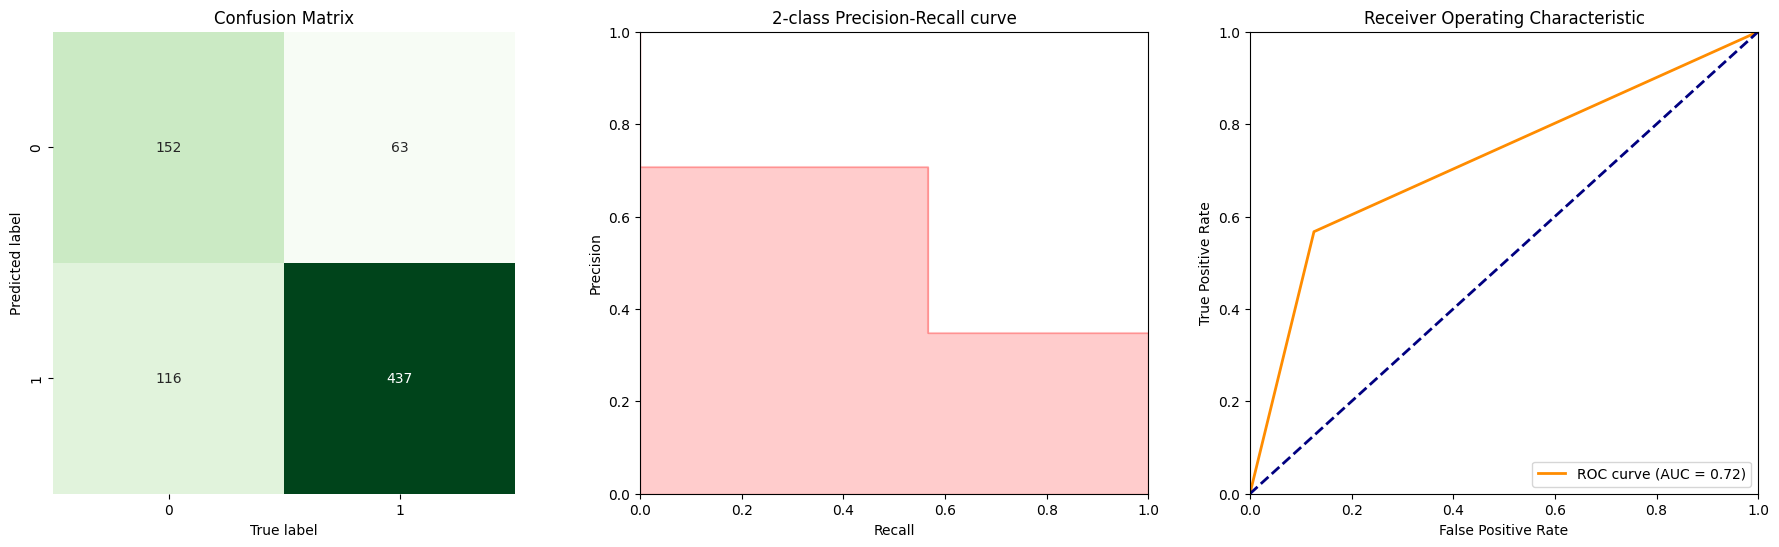

In [18]:
show_summary_report(y, logreg_y_pred_all)

# Random Forest Classifier

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from scipy import stats

# Features
X = diabetes.drop(columns=['Outcome'])

# Target
y = diabetes['Outcome']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)


from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rfc_y_pred_all = cross_val_predict(rfc, X, y, cv=kf)

In [21]:
rfc_results = diabetes.copy()
rfc_results['Random Forest Prediction'] = rfc_y_pred_all
rfc_results['Prediction Correct'] = (rfc_results['Random Forest Prediction'] == rfc_results['Outcome']).astype(int)
rfc_results

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Random Forest Prediction,Prediction Correct
0,6,148,72,35,0,33.6,0.627,50,1,1,1
1,1,85,66,29,0,26.6,0.351,31,0,0,1
2,8,183,64,0,0,23.3,0.672,32,1,1,1
3,1,89,66,23,94,28.1,0.167,21,0,0,1
4,0,137,40,35,168,43.1,2.288,33,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,0,1
764,2,122,70,27,0,36.8,0.340,27,0,0,1
765,5,121,72,23,112,26.2,0.245,30,0,0,1
766,1,126,60,0,0,30.1,0.349,47,1,1,1


In [22]:
rfc_results['Prediction Correct'].value_counts()

Prediction Correct
1    597
0    171
Name: count, dtype: int64

Accuracy : 0.7773 [TP / N]         Best: 1, Worst: 0
           Proportion of predicted labels that match the true labels.
Precision: 0.7195 [TP / (TP + FP)] Best: 1, Worst: 0
           Not to label a negative sample as positive.
Recall   : 0.5933 [TP / (TP + FN)] Best: 1, Worst: 0
           Find all the positive samples.
ROC AUC  : 0.7346                  Best: 1, Worst: < 0.5
--------------------------------------------------------------------------------
TP: True Positives, FP: False Positives,
TN: True Negatives, FN: False Negatives,
N: Number of samples


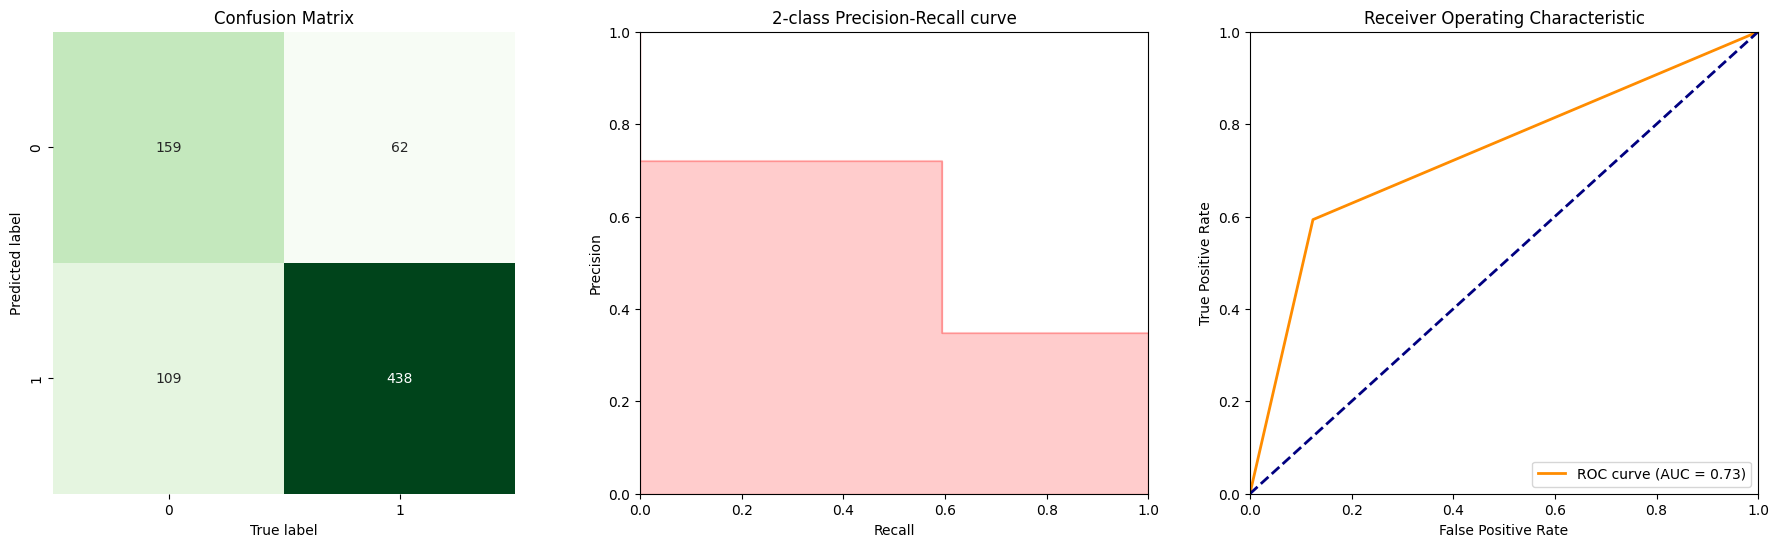

In [23]:
show_summary_report(y, rfc_y_pred_all)

# K-Means Clustering

In [27]:
X = diabetes.drop(columns=['Outcome'])

In [28]:
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

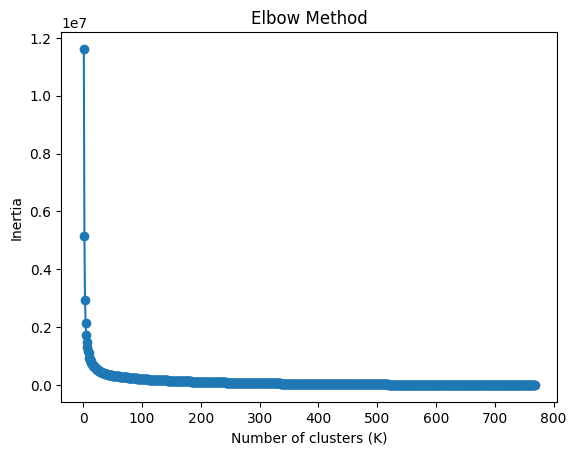

In [29]:
inertias = []
for i in range(1, len(X) + 1): # Max clusters can be equal to number of data points
    kmeans = KMeans(n_clusters=i, random_state=0, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, len(X) + 1), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.show()

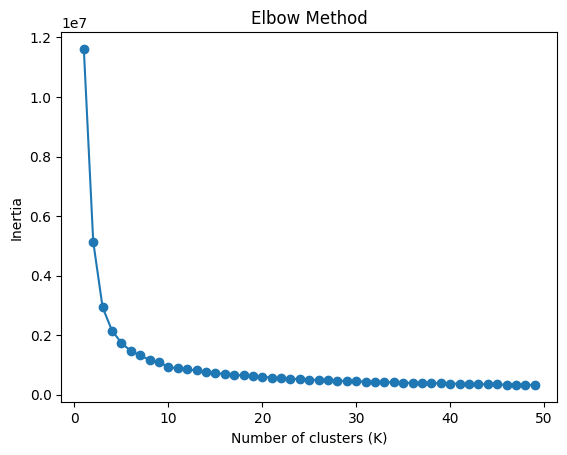

In [30]:
inertias = []
for i in range(1, 50): # Reduced range for legibility
    kmeans = KMeans(n_clusters=i, random_state=0, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 50), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [31]:
kmeans = KMeans(n_clusters=4, random_state=0, n_init='auto')
kmeans.fit(X)

KMeans(n_clusters=4, random_state=0)

In [34]:
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
print(f"Cluster Labels: {labels}")
print(f"Cluster Centroids: {centroids}")

Cluster Labels: [2 2 2 0 3 2 0 2 1 2 2 2 2 1 3 2 3 2 0 0 3 2 2 2 0 0 2 0 0 2 2 3 0 2 2 3 2
 2 2 3 0 2 2 3 2 2 2 2 2 2 0 2 2 3 3 2 3 0 2 0 2 2 2 0 2 2 2 2 2 0 0 0 2 3
 2 2 2 2 2 2 2 2 0 2 2 0 2 0 0 2 2 3 0 2 0 3 2 0 0 3 2 2 2 2 2 0 2 0 2 2 0
 1 2 2 3 2 2 2 2 0 0 2 0 2 2 0 0 0 0 2 3 2 3 2 2 0 0 0 2 3 2 2 0 2 3 2 2 0
 2 2 3 2 3 1 2 2 0 0 0 0 2 0 3 2 2 0 2 2 2 0 2 0 2 0 0 0 2 0 2 2 2 0 2 2 2
 2 1 0 0 3 2 0 2 2 2 3 2 2 0 3 2 2 2 2 3 2 3 2 0 2 2 2 2 0 3 3 0 0 2 2 1 2
 2 3 0 2 2 2 1 0 2 1 2 2 2 2 3 2 2 2 2 0 2 3 3 2 2 1 1 2 2 2 0 2 3 2 2 2 1
 0 0 2 2 2 2 0 2 2 2 2 2 0 2 0 2 0 2 0 2 3 2 0 0 2 2 0 1 3 2 0 2 0 3 3 2 0
 3 3 3 2 2 0 2 2 2 0 0 0 3 3 2 0 0 0 2 0 0 2 0 2 3 2 2 2 2 3 0 2 0 0 2 0 2
 2 0 3 2 2 3 2 0 0 2 2 2 0 0 2 0 2 2 2 2 2 2 2 3 2 0 3 3 2 2 2 3 0 2 2 0 0
 1 0 0 0 0 3 0 0 2 0 0 2 3 0 0 2 2 2 3 0 3 2 1 0 2 3 0 2 2 2 2 2 0 2 2 3 2
 2 2 1 2 3 3 0 3 1 2 2 2 0 3 0 0 2 3 3 2 3 0 3 2 0 0 2 2 2 2 2 2 2 2 0 0 2
 2 2 0 0 0 0 0 2 3 2 0 2 2 0 3 0 0 2 0 2 2 0 2 0 2 0 2 2 2 2 2 2 3 0 0 2 3
 2 2 0 2 

In [35]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='red', label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

InvalidIndexError: (slice(None, None, None), 0)